In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,r2_score,mean_squared_error,mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
import warnings
import pickle

In [2]:
df = pd.read_csv("/content/Mall_Customers.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
#stastical summary
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [4]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [7]:
#1. How many customers are present in the dataset?
customers = len(df)
customers

200

In [8]:
#2.  What is the gender distribution of customers?
gender_distribution = df['Gender'].value_counts()
gender_distribution

,count
Gender,
Female,112
Male,88


In [10]:
#3.  What is the average age, income, and spending score?
average_age = df['Age'].mean()
average_income = df['Annual Income (k$)'].mean()
average_spending_score = df['Spending Score (1-100)'].mean()
print("Average Age:", average_age)
print("Average Income:", average_income)
print("Average Spending Score:", average_spending_score)

Average Age: 38.85
Average Income: 60.56
Average Spending Score: 50.2


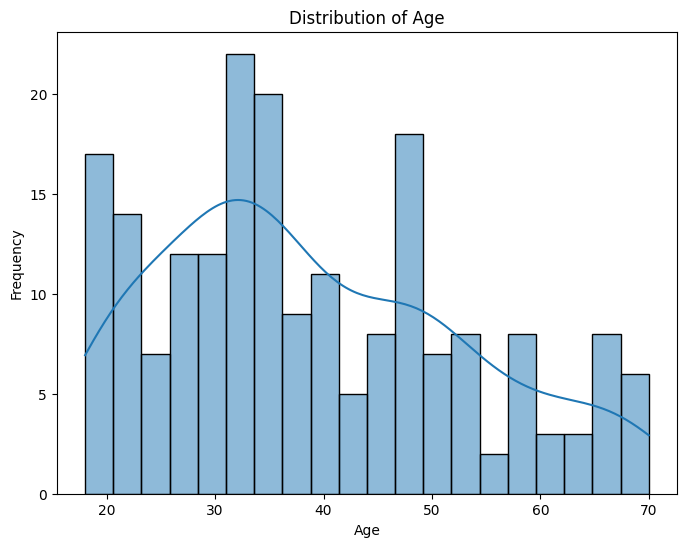

In [11]:
#4.  What is the distribution of Age?
plt.figure(figsize=(8, 6))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

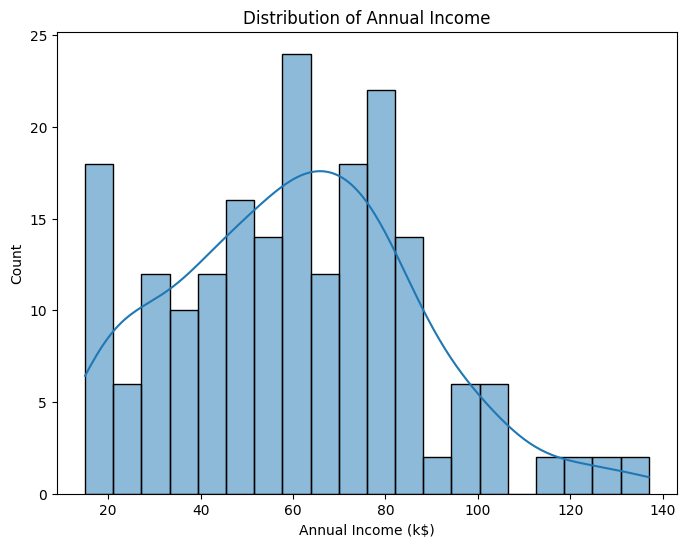

In [13]:
#5.  What is the distribution of Annual Income?
plt.figure(figsize=(8, 6))
sns.histplot(df['Annual Income (k$)'], bins=20, kde=True)
plt.title('Distribution of Annual Income')
plt.xlabel('Annual Income (k$)')
plt

Text(0, 0.5, 'Frequency')

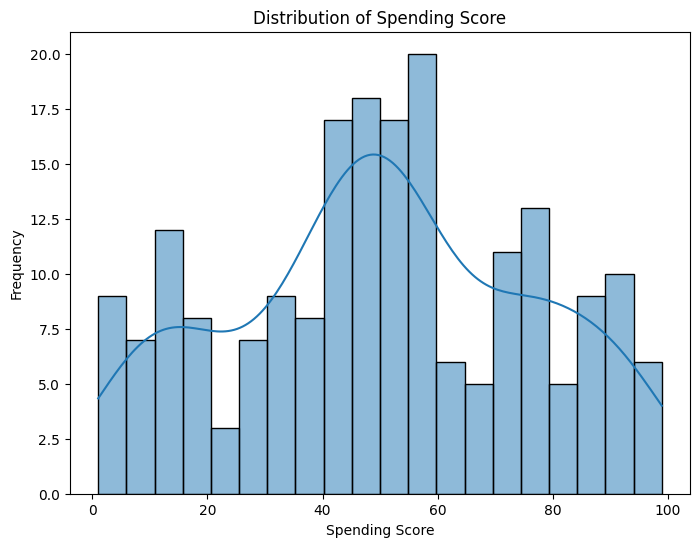

In [14]:
#6. What is the distribution of Spending Score?
plt.figure(figsize=(8, 6))
sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True)
plt.title('Distribution of Spending Score')
plt.xlabel('Spending Score')
plt.ylabel('Frequency')

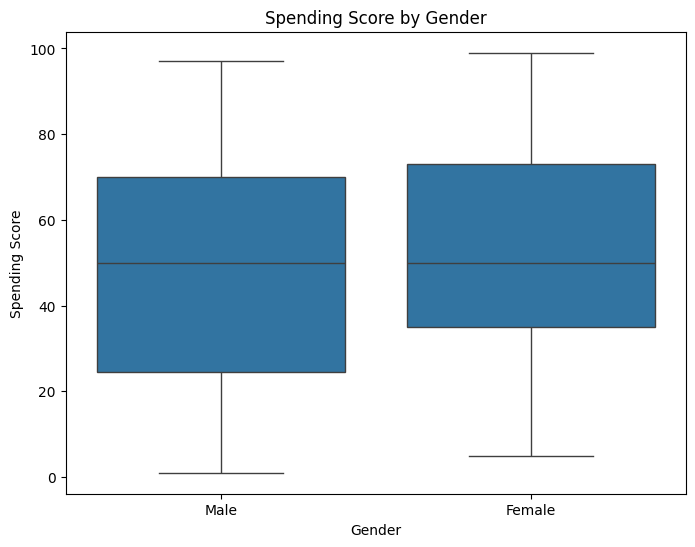

In [19]:
#7.  Do males and females have different spending behaviors?
male_spending = df[df['Gender'] == 'Male']['Spending Score (1-100)']
female_spending = df[df['Gender'] == 'Female']['Spending Score (1-100)']
plt.figure(figsize=(8, 6))
sns.boxplot(x='Gender', y='Spending Score (1-100)', data=df)
plt.title('Spending Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Spending Score')
plt.show()

In [20]:
#8.  Which gender has higher average income?
average_income_by_gender = df.groupby('Gender')['Annual Income (k$)'].mean()
higher_average_income_gender = average_income_by_gender.idxmax()
print("Gender with higher average income:", higher_average_income_gender)

Gender with higher average income: Male


Text(0.5, 1.0, 'Income vs. Spending Score')

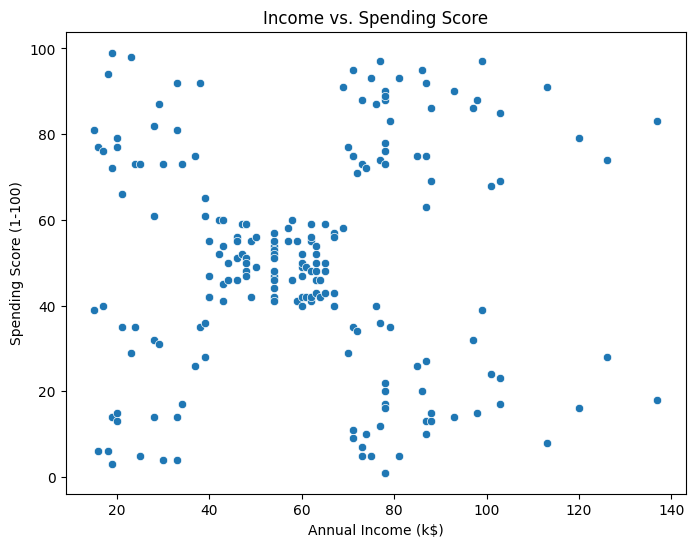

In [21]:
#9.  Does higher income lead to higher spending?
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df)
plt.title('Income vs. Spending Score')

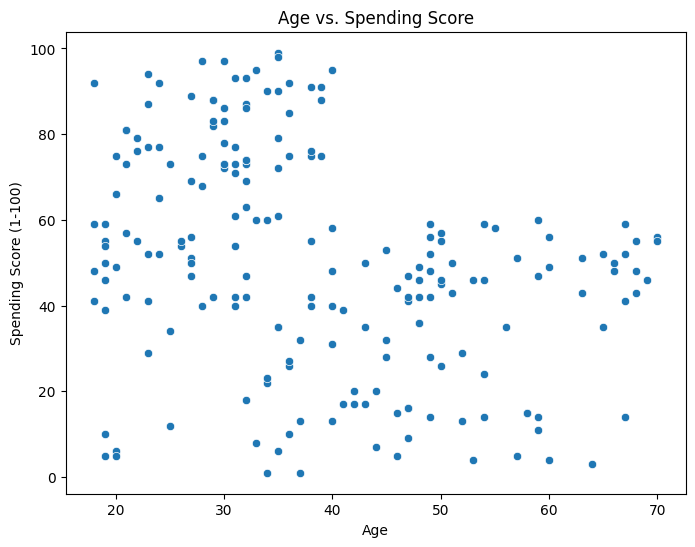

In [22]:
#10.  What is the relationship between Age and Spending Score?
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='Spending Score (1-100)', data=df)
plt.title('Age vs. Spending Score')
plt.show()

In [23]:
#11.  Which age group spends the most?
age_spending = df.groupby('Age')['Spending Score (1-100)'].mean()
most_spending_age = age_spending.idxmax()
print("Age group with the most spending:", most_spending_age)

Age group with the most spending: 39


In [27]:
from sklearn.cluster import KMeans
#12.  Can customers be grouped into distinct clusters?
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
kmeans = KMeans(n_clusters=5)
df['Cluster'] = kmeans.fit_predict(X)
cluster_counts = df['Cluster'].value_counts()
print("Cluster Counts:")
print(cluster_counts)

Cluster Counts:
Cluster
3    77
1    39
2    36
4    25
0    23
Name: count, dtype: int64


In [29]:
#13.  Are there high income and high spending customers?
high_income_spending = df[(df['Annual Income (k$)'] > 60) & (df['Spending Score (1-100)'] > 70)]
print("High Income and High Spending Customers:")
print(high_income_spending)

High Income and High Spending Customers:
     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
123         124    Male   39                  69                      91   
125         126  Female   31                  70                      77   
127         128    Male   40                  71                      95   
129         130    Male   38                  71                      75   
131         132    Male   39                  71                      75   
133         134  Female   31                  72                      71   
135         136  Female   29                  73                      88   
137         138    Male   32                  73                      73   
139         140  Female   35                  74                      72   
141         142    Male   32                  75                      93   
143         144  Female   32                  76                      87   
145         146    Male   28                  7

In [32]:
#14.  Are there low income but high spending customers?
low_income_high_spending = df[(df['Annual Income (k$)'] < 30) & (df['Spending Score (1-100)'] > 70)]
print("Low Income and High Spending Customers:")
print(low_income_high_spending)

Low Income and High Spending Customers:
    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
1            2    Male   21                  15                      81   
3            4  Female   23                  16                      77   
5            6  Female   22                  17                      76   
7            8  Female   23                  18                      94   
9           10  Female   30                  19                      72   
11          12  Female   35                  19                      99   
13          14  Female   24                  20                      77   
15          16    Male   22                  20                      79   
19          20  Female   35                  23                      98   
21          22    Male   25                  24                      73   
23          24    Male   31                  25                      73   
25          26    Male   29                  28             

In [35]:
#Featuring Engineering
x = df[['Age', 'Annual Income (k$)']]
y = df['Spending Score (1-100)']

In [34]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'Cluster'],
      dtype='object')

In [41]:
#Call the models

knn_model = KNeighborsClassifier()
NB_model = GaussianNB()
LR_model = LogisticRegression()
svm_model = SVC()

In [42]:
#Train test splits
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [43]:
#Training the models

knn_model.fit(X_train,y_train)
NB_model.fit(X_train,y_train)
LR_model.fit(X_train,y_train)
svm_model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


SVC()

In [45]:
#Testing the model

knn_pred = knn_model.predict(X_test)
NB_pred = NB_model.predict(X_test)
LR_pred = LR_model.predict(X_test)
svm_pred = svm_model.predict(X_test)

In [47]:
#Evaluation of the Models

print(classification_report(y_test,knn_pred))
print(confusion_matrix(y_test,knn_pred))
print(accuracy_score(y_test,knn_pred))

              precision    recall  f1-score   support

           1       0.50      1.00      0.67         1
           4       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         0
          10       0.00      0.00      0.00         0
          11       0.00      0.00      0.00         1
          13       0.00      0.00      0.00         2
          14       0.00      0.00      0.00         0
          15       0.00      0.00      0.00         1
          17       0.00      0.00      0.00         1
          20       0.00      0.00      0.00         1
          22       0.00      0.00      0.00         1
          24       0.00      0.00      0.00         1
          26       0.00      0.00      0.00         1
          28       0.00      0.00      0.00         0
          29       0.00      0.00      0.00         2
          34       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [48]:
# Creating a pickle file
filename = 'knn_model.pkl'
pickle.dump(knn_model, open(filename, 'wb'))